# MLflow tutorial

Tracking hyperparameter tuning with ML flow

In [1]:
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing


# MLflow config
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('MLflow optuna experiment')

2026/09/06 18:43:02 INFO mlflow.tracking.fluent: Experiment with name 'MLflow optuna experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/cyancy/Projects/quickstart_MLflow/mlruns/2', creation_time=1788691382133, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1788691382133, lifecycle_stage='active', name='MLflow optuna experiment', tags={}, trace_location=None, workspace='default'>

## Data import and organization

In [30]:
X, y = fetch_california_housing(return_X_y=True)
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=0)

### Data exploration

In [31]:
print(f'{X.shape = }')
print(f'{y.shape = }')

X.shape = (20640, 8)
y.shape = (20640,)


In [32]:
features = fetch_california_housing().feature_names
print(features)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


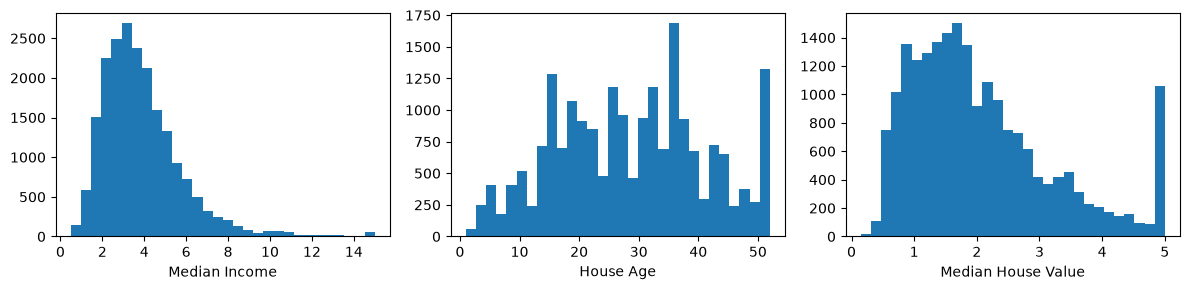

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
ax0, ax1, ax2 = axes

ax0.hist(X[:, 0], bins=30)
ax0.set_xlabel('Median Income')

ax1.hist(X[:, 1], bins=30)
ax1.set_xlabel('House Age')

ax2.hist(y, bins=30)
ax2.set_xlabel(r'Median House Value')

fig.tight_layout()
plt.show()

## Hyperparameter training

MLflow on top of optuna

In [38]:
def objective(trial):
    '''Tune the hyperparameters of a random forest regressor'''
    with mlflow.start_run(nested=True, run_name=f'trial_{trial.number}') as child_run:
        rf_max_depth = trial.suggest_int('rf_max_depth', 2, 32)
        rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 300, step=10)
        rf_max_features = trial.suggest_float('rf_max_features', 0.2, 1.0)

        params = {
            'max_depth': rf_max_depth,
            'n_estimators': rf_n_estimators,
            'max_features': rf_max_features
        }
        mlflow.log_params(params)

        regressor_obj = sklearn.ensemble.RandomForestRegressor(**params)
        regressor_obj.fit(X_train, y_train)

        y_pred = regressor_obj.predict(X_val)
        error = sklearn.metrics.mean_squared_error(y_val, y_pred)
        mlflow.log_metrics({'error': error})

        mlflow.sklearn.log_model(regressor_obj, name='model')
        trial.set_user_attr('run_id', child_run.info.run_id)
        return error

In [39]:
with mlflow.start_run(run_name='study') as run:
    n_trials = 30
    mlflow.log_param('n_trials', n_trials)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    mlflow.log_params(study.best_trial.params)
    mlflow.log_metrics({'best error': study.best_value})
    if best_run_id := study.best_trial.user_attrs.get('run_id'):
        mlflow.log_param('best_child_run_id', best_run_id)

[I 2026-09-06 20:19:10,336] A new study created in memory with name: no-name-d14c6914-9c8f-4968-8609-c45557c1b72d
[I 2026-09-06 20:19:21,130] Trial 0 finished with value: 0.24770924301666133 and parameters: {'rf_max_depth': 17, 'rf_n_estimators': 270, 'rf_max_features': 0.39228106547215713}. Best is trial 0 with value: 0.24770924301666133.
[I 2026-09-06 20:19:28,453] Trial 1 finished with value: 0.31496071992257013 and parameters: {'rf_max_depth': 9, 'rf_n_estimators': 230, 'rf_max_features': 0.38340314736334186}. Best is trial 0 with value: 0.24770924301666133.
[I 2026-09-06 20:19:41,071] Trial 2 finished with value: 0.2456620037250129 and parameters: {'rf_max_depth': 22, 'rf_n_estimators': 300, 'rf_max_features': 0.409496721973776}. Best is trial 2 with value: 0.2456620037250129.
[I 2026-09-06 20:19:55,734] Trial 3 finished with value: 0.2661982078522154 and parameters: {'rf_max_depth': 27, 'rf_n_estimators': 210, 'rf_max_features': 0.8959343624375271}. Best is trial 2 with value: 0.

In [46]:
print(study.best_trial.number)
print(study.best_trial.value)
print(study.best_trial.params)

23
0.24277931269994218
{'rf_max_depth': 29, 'rf_n_estimators': 140, 'rf_max_features': 0.46915310018111345}
